# Building an Agentic Corrective RAG System with LangGraph

# Agentic Corrective RAG (CRAG) System with LangGraph  

This is my end-to-end project demonstrating how I designed and implemented an **Agentic Corrective RAG (CRAG)** workflow inspired by the [Corrective Retrieval Augmented Generation](https://arxiv.org/pdf/2401.15884) paper.  

--

### My Design Focus  
- **My implementation tackles** the core challenge of RAG: poor retrieval quality that degrades LLM responses.  
- **My system ensures** context integrity by correcting retrieval errors and preventing hallucinations.  


### Key Problems in RAG I Addressed  
- Weak or noisy retrieval leading to irrelevant answers  
- Limited vector DB content causing missing context  
- Out-of-context or hallucinated responses  



### My Approach  
- I integrated **retrieval validation + fallback checks**.  
- When context is insufficient, **my solution triggers web search augmentation** before generating the final answer.  
- This design makes the pipeline more **robust, adaptive, and reliable** for real-world queries.  



### Workflow Overview  
![](https://i.imgur.com/uhybMhT.png)



### My Node-Based Design with LangGraph  

I structured this project as an **agentic RAG system** where each functionality is modeled as a **node** in the LangGraph.  
- **My approach maps** every task into a node that communicates with the LLM.  
- **Each node executes** targeted prompts for specific subtasks.  
- **This design enables** a modular and controllable workflow, as illustrated in the detailed pipeline below.  


![](https://i.imgur.com/eV87ZwX.gif)

## Install OpenAI, and LangChain dependencies

Install the following httpx library version for compatibility with other libraries

In [ ]:
!pip install httpx==0.27.2

In [ ]:
!pip install langchain==0.2.0
!pip install langchain-openai==0.1.7
!pip install langchain-community==0.2.0
!pip install langgraph==0.1.1
!pip install langchain-chroma==0.1.1

In [ ]:
!pip install --upgrade chromadb

  Using cached chromadb-1.0.20-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
Using cached chromadb-1.0.20-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (19.8 MB)
  Attempting uninstall: chromadb
    Found existing installation: chromadb 0.5.23
    Uninstalling chromadb-0.5.23:
      Successfully uninstalled chromadb-0.5.23
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-chroma 0.1.1 requires chromadb<0.6.0,>=0.4.0, but you have chromadb 1.0.20 which is incompatible.


## Enter Open AI API Key

In [ ]:
from getpass import getpass

OPENAI_KEY = getpass('Enter Open AI API Key: ')

Enter Open AI API Key: ··········


## Enter Tavily Search API Key

Get a free API key from [here](https://tavily.com/#api)

In [ ]:
TAVILY_API_KEY = getpass('Enter Tavily Search API Key: ')

Enter Tavily Search API Key: ··········


## Setup Environment Variables

In [ ]:
import os

os.environ['OPENAI_API_KEY'] = OPENAI_KEY
os.environ['TAVILY_API_KEY'] = TAVILY_API_KEY

## Build a Search Index for Wikipedia Data

We will build a vector database for retrieval and search by taking a subset of documents from wikipedia, similar to our project from previous modules

### Open AI Embedding Models

LangChain enables us to access Open AI embedding models which include the newest models: a smaller and highly efficient `text-embedding-3-small` model, and a larger and more powerful `text-embedding-3-large` model.

In [ ]:
from langchain_openai import OpenAIEmbeddings
openai_embed_model = OpenAIEmbeddings(model='text-embedding-3-small')

### Get the wikipedia data

In [ ]:
# go to https://drive.google.com/file/d/1oWBnoxBZ1Mpeond8XDUSO6J9oAjcRDyW download it
# manually upload it on colab
!gdown 1oWBnoxBZ1Mpeond8XDUSO6J9oAjcRDyW

Downloading...
From (original): https://drive.google.com/uc?id=1oWBnoxBZ1Mpeond8XDUSO6J9oAjcRDyW
From (redirected): https://drive.google.com/uc?id=1oWBnoxBZ1Mpeond8XDUSO6J9oAjcRDyW&confirm=t&uuid=22c49801-8d2b-4e28-9e31-e8dc1af91f08
To: /content/simplewiki-2020-11-01.jsonl.gz
100% 50.2M/50.2M [00:00<00:00, 182MB/s]


### Load and Chunk Documents

In [ ]:
import gzip
import json
from langchain.docstore.document import Document
from langchain.text_splitter import RecursiveCharacterTextSplitter

wikipedia_filepath = 'simplewiki-2020-11-01.jsonl.gz'

docs = []
with gzip.open(wikipedia_filepath, 'rt', encoding='utf8') as fIn:
    for line in fIn:
        data = json.loads(line.strip())
        #Add all paragraphs
        #passages.extend(data['paragraphs'])
        #Only add the first paragraph
        docs.append({
                        'metadata': {
                                        'title': data.get('title'),
                                        'article_id': data.get('id')
                        },
                        'data': ' '.join(data.get('paragraphs')[0:3]) # restrict data to first 3 paragraphs to run later modules faster
        })

# We subset our data so we only use a subset of wikipedia documents to run things faster
docs = [doc for doc in docs for x in ['india']
              if x in doc['data'].lower().split()]
# Create docs
docs = [Document(page_content=doc['data'],
                 metadata=doc['metadata']) for doc in docs]
# Chunk docs
splitter = RecursiveCharacterTextSplitter(chunk_size=2000, chunk_overlap=300)
chunked_docs = splitter.split_documents(docs)

In [ ]:
len(chunked_docs)

1322

In [ ]:
chunked_docs[:3]

[Document(metadata={'title': 'Basil', 'article_id': '73985'}, page_content='Basil ("Ocimum basilicum") ( or ) is a plant of the Family Lamiaceae. It is also known as Sweet Basil or Tulsi. It is a tender low-growing herb that is grown as a perennial in warm, tropical climates. Basil is originally native to India and other tropical regions of Asia. It has been cultivated there for more than 5,000 years. It is prominently featured in many cuisines throughout the world. Some of them are Italian, Thai, Vietnamese and Laotian cuisines. It grows to between 30–60\xa0cm tall. It has light green, silky leaves 3–5\xa0cm long and 1–3\xa0cm broad. The leaves are opposite each other. The flowers are quite big. They are white in color and arranged as a spike. The plant tastes somewhat like anise, with a strong, pungent, sweet smell. Basil is very sensitive to cold. It is best grown in hot, dry conditions. While most common varieties are treated as annuals, some are perennial, including African Blue a

### Create a Vector DB and persist on disk

Here we initialize a connection to a Chroma vector DB client, and also we want to save to disk, so we simply initialize the Chroma client and pass the directory where we want the data to be saved to.

In [ ]:
from langchain_chroma import Chroma

# create vector DB of docs and embeddings.
chroma_db = Chroma.from_documents(documents=chunked_docs,
                                  collection_name='rag_wikipedia_db',
                                  embedding=openai_embed_model,
                                  # need to set the distance function to cosine else it uses euclidean by default
                                  collection_metadata={"hnsw:space": "cosine"},
                                  persist_directory="./wikipedia_db")

### My Vector Database Retriever Setup  

In my project, I designed the retriever to follow a **similarity + threshold** strategy, ensuring only meaningful context is passed to the LLM.


### My Similarity + Threshold Retrieval  

I apply **cosine similarity** and fetch the **top-3 most relevant documents** for each query.  
To avoid noisy results, my retriever **drops any documents falling below a set similarity cutoff**, keeping the context precise and reliable.

In [ ]:
similarity_threshold_retriever = chroma_db.as_retriever(search_type="similarity_score_threshold",
                                                        search_kwargs={"k": 3,
                                                                       "score_threshold": 0.3})

In [ ]:
query = "what is the capital of India?"
top3_docs = similarity_threshold_retriever.invoke(query)
top3_docs

[Document(metadata={'title': 'New Delhi', 'article_id': '5117'}, page_content='New Delhi () is the capital of India and a union territory of the megacity of Delhi. It has a very old history and is home to several monuments where the city is expensive to live in. In traditional Indian geography it falls under the North Indian zone. The city has an area of about 42.7\xa0km. New Delhi has a population of about 9.4 Million people.'),
 Document(metadata={'article_id': '5117', 'title': 'New Delhi'}, page_content='New Delhi () is the capital of India and a union territory of the megacity of Delhi. It has a very old history and is home to several monuments where the city is expensive to live in. In traditional Indian geography it falls under the North Indian zone. The city has an area of about 42.7\xa0km. New Delhi has a population of about 9.4 Million people.'),
 Document(metadata={'title': 'New Delhi', 'article_id': '5117'}, page_content='New Delhi () is the capital of India and a union terr

In [ ]:
query = "what is langgraph?"
top3_docs = similarity_threshold_retriever.invoke(query)
top3_docs

[]

## Create a Query Retrieval Grader

Here I will use an LLM itself to grade if any retrieved document is relevant to the given question - Answer will be either `yes` or `no`

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.pydantic_v1 import BaseModel, Field
from langchain_openai import ChatOpenAI


# Data model for LLM output format
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""
    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )


# LLM for grading
llm = ChatOpenAI(model="gpt-4o", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# Prompt template for grading
SYS_PROMPT = """You are an expert grader assessing relevance of a retrieved document to a user question.
                Follow these instructions for grading:
                  - If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant.
                  - Your grade should be either 'yes' or 'no' to indicate whether the document is relevant to the question or not.
             """
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", SYS_PROMPT),
        ("human", """Retrieved document:
                     {document}

                     User question:
                     {question}
                  """),
    ]
)

# Build grader chain
doc_grader = (grade_prompt
                  |
              structured_llm_grader)

In [ ]:
query = "what is the capital of India?"
top3_docs = similarity_threshold_retriever.invoke(query)
for doc in top3_docs:
    print(doc.page_content)
    print('GRADE:', doc_grader.invoke({"question": query, "document": doc.page_content}))
    print()

New Delhi () is the capital of India and a union territory of the megacity of Delhi. It has a very old history and is home to several monuments where the city is expensive to live in. In traditional Indian geography it falls under the North Indian zone. The city has an area of about 42.7 km. New Delhi has a population of about 9.4 Million people.
GRADE: binary_score='yes'

New Delhi () is the capital of India and a union territory of the megacity of Delhi. It has a very old history and is home to several monuments where the city is expensive to live in. In traditional Indian geography it falls under the North Indian zone. The city has an area of about 42.7 km. New Delhi has a population of about 9.4 Million people.
GRADE: binary_score='yes'

New Delhi () is the capital of India and a union territory of the megacity of Delhi. It has a very old history and is home to several monuments where the city is expensive to live in. In traditional Indian geography it falls under the North Indian 

In [ ]:
query = "what is langgraph?"
top3_docs = similarity_threshold_retriever.invoke(query)
for doc in top3_docs:
    print(doc.page_content)
    print('GRADE:', doc_grader.invoke({"question": query, "document": doc.page_content}))
    print()

In [ ]:
query = "who won the champions league in 2024?"
top3_docs = similarity_threshold_retriever.invoke(query)
for doc in top3_docs:
    print(doc.page_content)
    print('GRADE:', doc_grader.invoke({"question": query, "document": doc.page_content}))
    print()

The 2023 ICC Cricket World Cup is scheduled to be hosted by India and India was selected as the host at an International Cricket Council (ICC) meeting in London in June 2013. This will be the 13th Cricket World Cup competition. It will be the fourth time that India will be the host. This will be the first time that India has hosted the tournament on its own. India hosted previous World Cup tournaments in 1987 (with Pakistan), 1996 (with Pakistan and Sri Lanka) and 2011 (with Sri Lanka and Bangladesh). The semi final will be played at Wankhede Stadium. And final will be played at Eden Gardens, Kolkata. 5. ICC Cricket Worldcup 2023 Venue
GRADE: binary_score='no'

The 2023 ICC Cricket World Cup is scheduled to be hosted by India and India was selected as the host at an International Cricket Council (ICC) meeting in London in June 2013. This will be the 13th Cricket World Cup competition. It will be the fourth time that India will be the host. This will be the first time that India has hos

## Build a QA RAG Chain

I will now connect our retriever to an LLM and build our QA RAG Chain

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser
from operator import itemgetter

prompt = """You are an assistant for question-answering tasks.
            Use the following pieces of retrieved context to answer the question.
            If no context is present or if you don't know the answer, just say that you don't know the answer.
            Do not make up the answer unless it is there in the provided context.
            Give a detailed answer and to the point answer with regard to the question.

            Question:
            {question}

            Context:
            {context}

            Answer:
         """
prompt_template = ChatPromptTemplate.from_template(prompt)

chatgpt = ChatOpenAI(model_name='gpt-4o', temperature=0)

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

qa_rag_chain = (
    {
        "context": (itemgetter('context')
                        |
                    RunnableLambda(format_docs)),
        "question": itemgetter('question')
    }
      |
    prompt_template
      |
    chatgpt
      |
    StrOutputParser()
)

In [ ]:
query = "what is the capital of India?"
top3_docs = similarity_threshold_retriever.invoke(query)
result = qa_rag_chain.invoke(
    {"context": top3_docs, "question": query}
)
print(result)

The capital of India is New Delhi. It is also a union territory within the larger megacity of Delhi.


In [ ]:
query = "who won the champions league in 2024?"
top3_docs = similarity_threshold_retriever.invoke(query)
result = qa_rag_chain.invoke(
    {"context": top3_docs, "question": query}
)
print(result)

I don't know the answer. The provided context does not contain information about the winner of the Champions League in 2024.


## Create a Query Rephraser

I will now build a query rephraser which will use an LLM to rephrase the input user query into a better version which is optimized for web search

In [ ]:
# LLM for question rewriting
llm = ChatOpenAI(model="gpt-4o", temperature=0)

# Prompt template for rewriting
SYS_PROMPT = """Act as a question re-writer and perform the following task:
                 - Convert the following input question to a better version that is optimized for web search.
                 - When re-writing, look at the input question and try to reason about the underlying semantic intent / meaning.
             """
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", SYS_PROMPT),
        ("human", """Here is the initial question:
                     {question}

                     Formulate an improved question.
                  """,
        ),
    ]
)

question_rewriter = (re_write_prompt
                        |
                       llm
                        |
                     StrOutputParser())

In [ ]:
query = "who won the champions league in 2024?"
question_rewriter.invoke({"question": query})

'Who was the winner of the 2024 UEFA Champions League?'

## Load Web Search Tool

Here we will be using the [Tavily API](https://tavily.com/#api) for our web searches

In [ ]:
from langchain_community.tools.tavily_search import TavilySearchResults

tv_search = TavilySearchResults(max_results=3, search_depth='advanced',
                                max_tokens=10000)

In [ ]:
from langchain_community.tools.tavily_search import TavilySearchResults

tv_search = TavilySearchResults(max_results=3, search_depth='advanced',
                                max_tokens=10000)

## Build Agentic RAG components

Here I will build the key components of our Agentic Corrective RAG System as per the workflow below:

![](https://i.imgur.com/uhybMhT.png)



### Graph State

Used to store and represent the state of the agent graph as we traverse through various nodes

In [ ]:
from typing import List
from typing_extensions import TypedDict

class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM response generation
        web_search_needed: flag of whether to add web search - yes or no
        documents: list of context documents
    """

    question: str
    generation: str
    web_search_needed: str
    documents: List[str]

### Retrieve function for retrieval from Vector DB

This will be used to get relevant context documents from the vector database

In [ ]:
def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents - that contains retrieved context documents
    """
    print("---RETRIEVAL FROM VECTOR DB---")
    question = state["question"]

    # Retrieval
    documents = similarity_threshold_retriever.invoke(question)
    return {"documents": documents, "question": question}

### Grade documents

This will be used to determine whether the retrieved documents are relevant to the question by using an LLM Grader

Sets the `web_search_needed` flag as `Yes` if at least one document is not contextually relevant and sets it as `No` if all documents are contextually relevant to the given user query

In [ ]:
def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question
    by using an LLM Grader.

    If any document are not relevant to question or documents are empty - Web Search needs to be done
    If all documents are relevant to question - Web Search is not needed
    Helps filtering out irrelevant documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    web_search_needed = "No"
    if documents:
        for d in documents:
            score = doc_grader.invoke(
                {"question": question, "document": d.page_content}
            )
            grade = score.binary_score
            if grade == "yes":
                print("---GRADE: DOCUMENT RELEVANT---")
                filtered_docs.append(d)
            else:
                print("---GRADE: DOCUMENT NOT RELEVANT---")
                web_search_needed = "Yes"
                continue
    else:
        print("---NO DOCUMENTS RETRIEVED---")
        web_search_needed = "Yes"

    return {"documents": filtered_docs, "question": question, "web_search_needed": web_search_needed}

### Rewrite query

This will be used to rewrite the input query to produce a better question optimized for web search using an LLM

In [ ]:
def rewrite_query(state):
    """
    Rewrite the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased or re-written question
    """

    print("---REWRITE QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    # print(f"Original: {question}")
    # print(f"Rewritten: {better_question}")
    return {"documents": documents, "question": better_question}

### Web Search

This will be used to search the web using the web search tool for the given query and retrieve some information which can be used as the context in RAG

In [ ]:
from langchain.schema import Document

def web_search(state):
    """
    Web search based on the re-written question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    print("---WEB SEARCH---")
    question = state["question"]
    documents = state["documents"]

    # Web search
    docs = tv_search.invoke(question)
    web_results = "\n\n".join([d["content"] for d in docs])
    web_results = Document(page_content=web_results)
    documents.append(web_results)

    return {"documents": documents, "question": question}

### Generate Answer

Standard LLM Response generation from query and context documents in a RAG system

In [ ]:
def generate_answer(state):
    """
    Generate answer from context document using LLM

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE ANSWER---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = qa_rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}

### Decide to Generate

This will be used as a conditional function which will check the `web_search_needed` flag and decide if a web search is needed or a response should be generated and return the function name to be called

In [ ]:
def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    web_search_needed = state["web_search_needed"]

    if web_search_needed == "Yes":
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print("---DECISION: SOME or ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, REWRITE QUERY---")
        return "rewrite_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE RESPONSE---")
        return "generate_answer"

### Build the Agent Graph

Here we will use LangGraph and build the agent as a graph

In [ ]:
from langgraph.graph import END, StateGraph

agentic_rag = StateGraph(GraphState)

# Define the nodes
agentic_rag.add_node("retrieve", retrieve)  # retrieve
agentic_rag.add_node("grade_documents", grade_documents)  # grade documents
agentic_rag.add_node("rewrite_query", rewrite_query)  # transform_query
agentic_rag.add_node("web_search", web_search)  # web search
agentic_rag.add_node("generate_answer", generate_answer)  # generate answer

# Build graph
agentic_rag.set_entry_point("retrieve")
agentic_rag.add_edge("retrieve", "grade_documents")
agentic_rag.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {"rewrite_query": "rewrite_query", "generate_answer": "generate_answer"},
)
agentic_rag.add_edge("rewrite_query", "web_search")
agentic_rag.add_edge("web_search", "generate_answer")
agentic_rag.add_edge("generate_answer", END)

# Compile
agentic_rag = agentic_rag.compile()

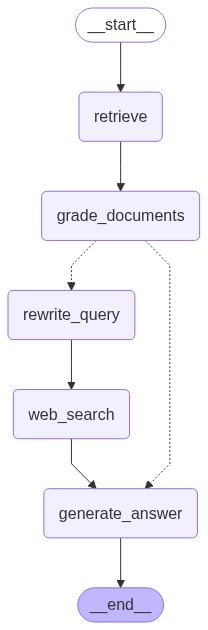

In [ ]:
from IPython.display import Image, display, Markdown

display(Image(agentic_rag.get_graph().draw_mermaid_png()))

## Test the Agentic CRAG System

In [ ]:
query = "what is the capital of India?"
response = agentic_rag.invoke({"question": query})

---RETRIEVAL FROM VECTOR DB---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE RESPONSE---
---GENERATE ANSWER---


In [ ]:
display(Markdown(response['generation']))

The capital of India is New Delhi. It is also a union territory within the larger megacity of Delhi.

In [ ]:
response

{'question': 'what is the capital of India?',
 'generation': 'The capital of India is New Delhi. It is also a union territory within the larger megacity of Delhi.',
 'web_search_needed': 'No',
 'documents': [Document(metadata={'title': 'New Delhi', 'article_id': '5117'}, page_content='New Delhi () is the capital of India and a union territory of the megacity of Delhi. It has a very old history and is home to several monuments where the city is expensive to live in. In traditional Indian geography it falls under the North Indian zone. The city has an area of about 42.7\xa0km. New Delhi has a population of about 9.4 Million people.'),
  Document(metadata={'article_id': '5117', 'title': 'New Delhi'}, page_content='New Delhi () is the capital of India and a union territory of the megacity of Delhi. It has a very old history and is home to several monuments where the city is expensive to live in. In traditional Indian geography it falls under the North Indian zone. The city has an area of a

In [ ]:
query = "who won the champions league in 2024?"
response = agentic_rag.invoke({"question": query})

---RETRIEVAL FROM VECTOR DB---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: SOME or ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, REWRITE QUERY---
---REWRITE QUERY---


KeyError: "Input to ChatPromptTemplate is missing variables {'conversation_history'}.  Expected: ['conversation_history', 'question'] Received: ['question']\nNote: if you intended {conversation_history} to be part of the string and not a variable, please escape it with double curly braces like: '{{conversation_history}}'."

In [ ]:
display(Markdown(response['generation']))

Real Madrid were the winners of the 2024 UEFA Champions League. They secured their victory with a 2-0 win over Borussia Dortmund in the final, which was held at Wembley Stadium. This victory marked Real Madrid's record-extending 15th European Cup/UEFA Champions League title.

In [ ]:
query = "Tell
response = agentic_rag.invoke({"question": query}) me about India"

---RETRIEVAL FROM VECTOR DB---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE RESPONSE---
---GENERATE ANSWER---


In [ ]:
display(Markdown(response['generation']))

India is a country located in Asia, specifically at the center of South Asia. It is the seventh largest country in the world by area and the largest in South Asia. With a population exceeding 1.2 billion people, India is the second most populous country globally and holds the distinction of being the most populous democracy in the world.

Geographically, India is a peninsula, bordered by the Indian Ocean to the south, the Arabian Sea to the west, and the Bay of Bengal to the east. It shares its borders with seven countries: Pakistan to the northwest, China and Nepal to the north, Bhutan and Bangladesh to the northeast, Myanmar to the east, and Sri Lanka, an island nation, to the south.

The capital city of India is New Delhi. The country has a significant military presence, being home to the third largest military force in the world, and it is recognized as a nuclear weapon state.

In [ ]:
query = "     "
response = agentic_rag.invoke({"question": query})

---RETRIEVAL FROM VECTOR DB---


---CHECK DOCUMENT RELEVANCE TO QUESTION---
---NO DOCUMENTS RETRIEVED---
---ASSESS GRADED DOCUMENTS---
---DECISION: SOME or ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, REWRITE QUERY---
---REWRITE QUERY---
Original:      
Rewritten: How can I create a more effective question for web searches?
---WEB SEARCH---
---GENERATE ANSWER---


In [ ]:
display(Markdown(response['generation']))

##Multi-user conversational chatbot *powered by* CRAG

We now wrap the previously built **Agentic Corrective RAG (CRAG)** graph into a multi-user chatbot.

- Each user/session is identified by a `thread_id`.
- We use `SqliteSaver` to persist conversation state per user.
- The chatbot node **does not hallucinate**: it calls the CRAG graph under the hood, which:

  1) retrieves from the Chroma vector DB,

  2) grades relevance with the LLM,

  3) conditionally rewrites & performs web search (Tavily),

  4) generates a grounded answer via the QA chain.

In [ ]:
# removes the memory database file - usually not needed
# you can run this only when you want to remove ALL conversation histories
# ok if you get rm: cannot remove 'memory.db': No such file or directory because initially no memory exists
!rm memory.db*

In [ ]:
from typing import Annotated
from langchain_core.messages import BaseMessage
from typing_extensions import TypedDict
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langgraph.checkpoint.sqlite import SqliteSaver

# used to retrieve conversation history from database
# based on a specific user or session ID - thread_id
memory = SqliteSaver.from_conn_string("memory.db")

# Enhanced Graph State for Conversational CRAG
We need to modify our graph state to handle both conversational messages and CRAG workflow data.

In [ ]:
from typing import List
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage

class ConversationalCRAGState(TypedDict):
    """
    Enhanced state for conversational CRAG system.

    Attributes:
        messages: conversation history with user
        question: current user question extracted from latest message
        generation: LLM response generation
        web_search_needed: flag of whether to add web search - yes or no
        documents: list of context documents
    """
    messages: Annotated[list, add_messages]
    question: str
    generation: str
    web_search_needed: str
    documents: List[str]

#Enhanced QA RAG Chain with Conversation Context
Now we'll adapt our CRAG functions to work with the conversational state:

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser
from operator import itemgetter

# Enhanced prompt that considers conversation history
conversation_aware_prompt = """You are an assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.
Also consider the conversation history to understand references like "this city", "that match", etc.

If no context is present or if you don't know the answer, just say that you don't know the answer.
Do not make up the answer unless it is there in the provided context.
Give a detailed and to-the-point answer with regard to the question.

Conversation History:
{conversation_history}

Current Question:
{question}

Retrieved Context:
{context}

Answer:
"""

conversation_prompt_template = ChatPromptTemplate.from_template(conversation_aware_prompt)

def format_conversation_history(messages):
    """Format conversation history for context"""
    if not messages or len(messages) <= 1:
        return "No previous conversation."

    # Get last few messages for context (excluding current question)
    history = []
    for msg in messages[:-1]:  # Exclude the current message
        if hasattr(msg, 'content'):
            role = "Human" if hasattr(msg, 'type') and msg.type == "human" else "Assistant"
            history.append(f"{role}: {msg.content}")

    return "\n".join(history[-4:])  # Last 4 messages for context

qa_rag_chain = (
    {
        "context": (itemgetter('context') | RunnableLambda(format_docs)),
        "question": itemgetter('question'),
        "conversation_history": (itemgetter('messages') | RunnableLambda(format_conversation_history))
    }
    | conversation_prompt_template
    | chatgpt
    | StrOutputParser()
)

#Enhanced Query Rewriter with Conversation Context

In [ ]:
# Enhanced rewriter that considers conversation context
context_aware_rewrite_prompt = """Act as a question re-writer that considers conversation context.

Conversation History:
{conversation_history}

Current Question:
{question}

Task:
1. Look at the conversation history to understand what the user is referring to
2. If the question contains references like "this city", "that match", "the country", etc.,
   replace them with the actual entities from the conversation history
3. Convert the question to a better version optimized for web search
4. Maintain the original intent while making it more specific and searchable

Provide only the improved question without any explanation.
"""

context_aware_rewrite_template = ChatPromptTemplate.from_template(context_aware_rewrite_prompt)

question_rewriter = (context_aware_rewrite_template | llm | StrOutputParser())

#Complete Enhanced Node Functions

In [ ]:
def extract_question(state):
    """Extract question and prepare conversation context"""
    print("---EXTRACTING USER QUESTION---")
    messages = state["messages"]
    user_message = messages[-1].content if messages else ""
    return {"question": user_message, "messages": messages}

def conversational_retrieve(state):
    """Retrieve documents with better logging"""
    print("---RETRIEVAL FROM VECTOR DB---")
    question = state["question"]
    messages = state["messages"]

    documents = similarity_threshold_retriever.invoke(question)
    print(f"Retrieved {len(documents)} documents")
    return {"documents": documents, "question": question, "messages": messages}

def conversational_grade_documents(state):
    """Grade documents with improved logic - only web search if NO docs are relevant"""
    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]
    messages = state["messages"]

    filtered_docs = []
    web_search_needed = "No"

    if documents:
        relevant_count = 0
        for d in documents:
            score = doc_grader.invoke(
                {"question": question, "document": d.page_content}
            )
            grade = score.binary_score
            if grade == "yes":
                print("---GRADE: DOCUMENT RELEVANT---")
                filtered_docs.append(d)
                relevant_count += 1
            else:
                print("---GRADE: DOCUMENT NOT RELEVANT---")

        # Only trigger web search if NO documents are relevant
        if relevant_count == 0:
            web_search_needed = "Yes"
            print(f"---NO RELEVANT DOCUMENTS FOUND, WEB SEARCH NEEDED---")
        else:
            print(f"---FOUND {relevant_count} RELEVANT DOCUMENTS---")
    else:
        print("---NO DOCUMENTS RETRIEVED, WEB SEARCH NEEDED---")
        web_search_needed = "Yes"

    return {
        "documents": filtered_docs,
        "question": question,
        "messages": messages,
        "web_search_needed": web_search_needed
    }

def conversational_rewrite_query(state):
    """Rewrite query with conversation context"""
    print("---REWRITE QUERY WITH CONTEXT---")
    question = state["question"]
    documents = state["documents"]
    messages = state["messages"]

    conversation_history = format_conversation_history(messages)

    better_question = question_rewriter.invoke({
        "question": question,
        "conversation_history": conversation_history
    })

    print(f"Original: {question}")
    print(f"Rewritten: {better_question}")

    return {"documents": documents, "question": better_question, "messages": messages}

def conversational_web_search(state):
    """Web search with context awareness"""
    print("---WEB SEARCH---")
    question = state["question"]
    documents = state["documents"]
    messages = state["messages"]

    docs = tv_search.invoke(question)
    web_results = "\n\n".join([d["content"] for d in docs])
    web_results = Document(page_content=web_results)

    # Add web results to existing documents (don't replace them)
    all_documents = documents + [web_results]

    return {"documents": all_documents, "question": question, "messages": messages}

def conversational_generate_answer(state):
    """Generate answer with conversation context"""
    print("---GENERATE ANSWER---")
    question = state["question"]
    documents = state["documents"]
    messages = state["messages"]

    # Use RAG chain
    generation = qa_rag_chain.invoke({
        "context": documents,
        "question": question,
        "messages": messages
    })

    from langchain_core.messages import AIMessage
    response_message = AIMessage(content=generation)

    return {
        "documents": documents,
        "question": question,
        "messages": messages + [response_message],
        "generation": generation
    }

def conversational_decide_to_generate(state):
    """Improved decision logic - only web search if NO relevant docs"""
    print("---ASSESS GRADED DOCUMENTS---")
    web_search_needed = state["web_search_needed"]

    if web_search_needed == "Yes":
        print("---DECISION: NO RELEVANT DOCUMENTS FOUND, REWRITE QUERY FOR WEB SEARCH---")
        return "conversational_rewrite_query"
    else:
        print("---DECISION: RELEVANT DOCUMENTS FOUND, GENERATE RESPONSE---")
        return "conversational_generate_answer"

#Build the Complete Enhanced Conversational CRAG Graph

In [ ]:
from langgraph.graph import END, StateGraph

# Create conversational CRAG graph
conversational_agentic_rag = StateGraph(ConversationalCRAGState)

# Define all the nodes
conversational_agentic_rag.add_node("extract_question", extract_question)
conversational_agentic_rag.add_node("conversational_retrieve", conversational_retrieve)
conversational_agentic_rag.add_node("conversational_grade_documents", conversational_grade_documents)
conversational_agentic_rag.add_node("conversational_rewrite_query", conversational_rewrite_query)
conversational_agentic_rag.add_node("conversational_web_search", conversational_web_search)
conversational_agentic_rag.add_node("conversational_generate_answer", conversational_generate_answer)

# Build the complete graph
conversational_agentic_rag.set_entry_point("extract_question")
conversational_agentic_rag.add_edge("extract_question", "conversational_retrieve")
conversational_agentic_rag.add_edge("conversational_retrieve", "conversational_grade_documents")
conversational_agentic_rag.add_conditional_edges(
    "conversational_grade_documents",
    conversational_decide_to_generate,
    {
        "conversational_rewrite_query": "conversational_rewrite_query",
        "conversational_generate_answer": "conversational_generate_answer"
    },
)
conversational_agentic_rag.add_edge("conversational_rewrite_query", "conversational_web_search")
conversational_agentic_rag.add_edge("conversational_web_search", "conversational_generate_answer")
conversational_agentic_rag.add_edge("conversational_generate_answer", END)

# Compile with memory checkpointer
crag_graph = conversational_agentic_rag.compile(checkpointer=memory)

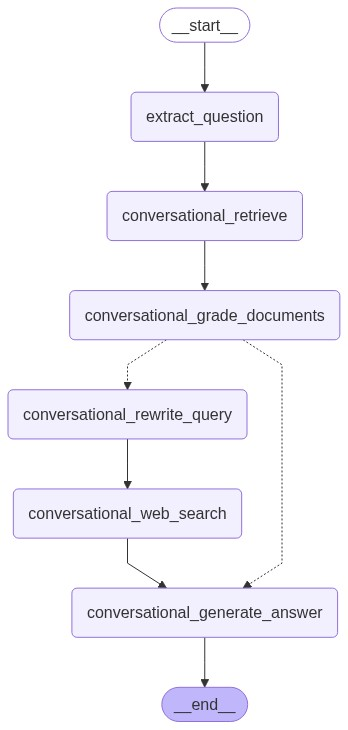

In [ ]:
from IPython.display import Image, display, Markdown

display(Image(crag_graph.get_graph().draw_mermaid_png()))

In [ ]:
def chat_with_crag_agent(prompt: str, session_id: str):
    """Chat function with better error handling and context awareness"""
    from langchain_core.messages import HumanMessage

    try:
        response = crag_graph.invoke(
            {"messages": [HumanMessage(content=prompt)]},
            {'configurable': {'thread_id': session_id}}
        )

        # Display the latest AI response
        display(Markdown(response['messages'][-1].content))
        return response
    except Exception as e:
        print(f"Error: {e}")
        return None

#Test the Multi-User Conversational CRAG System

In [ ]:
print("=== Testing India Questions (Local Documents) ===")
user_id = 'sushma'
prompt = "What is the capital of India?"
chat_with_crag_agent(prompt, user_id)

=== Testing India Questions (Local Documents) ===
---EXTRACTING USER QUESTION---
---RETRIEVAL FROM VECTOR DB---
Retrieved 3 documents
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---FOUND 3 RELEVANT DOCUMENTS---
---ASSESS GRADED DOCUMENTS---
---DECISION: RELEVANT DOCUMENTS FOUND, GENERATE RESPONSE---
---GENERATE ANSWER---


The capital of India is New Delhi.

{'messages': [HumanMessage(content='What is the capital of India?', id='a09d3998-8e3d-4384-be21-19ef370289f7'),
  AIMessage(content='The capital of India is New Delhi.', id='d28b5239-0c81-4d59-a083-076404e2d23b')],
 'question': 'What is the capital of India?',
 'generation': 'The capital of India is New Delhi.',
 'web_search_needed': 'No',
 'documents': [Document(metadata={'title': 'New Delhi', 'article_id': '5117'}, page_content='New Delhi () is the capital of India and a union territory of the megacity of Delhi. It has a very old history and is home to several monuments where the city is expensive to live in. In traditional Indian geography it falls under the North Indian zone. The city has an area of about 42.7\xa0km. New Delhi has a population of about 9.4 Million people.'),
  Document(metadata={'title': 'New Delhi', 'article_id': '5117'}, page_content='New Delhi () is the capital of India and a union territory of the megacity of Delhi. It has a very old history and is home to seve

In [ ]:
user_id = 'sushma'
prompt = "Tell me more about this city"
chat_with_crag_agent(prompt, user_id)

---EXTRACTING USER QUESTION---
---RETRIEVAL FROM VECTOR DB---


Retrieved 0 documents
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---NO DOCUMENTS RETRIEVED, WEB SEARCH NEEDED---
---ASSESS GRADED DOCUMENTS---
---DECISION: NO RELEVANT DOCUMENTS FOUND, REWRITE QUERY FOR WEB SEARCH---
---REWRITE QUERY WITH CONTEXT---
Original: Tell me more about this city
Rewritten: Can you provide more information about New Delhi?
---WEB SEARCH---
---GENERATE ANSWER---


New Delhi, the capital of India, is a vibrant and bustling metropolis that forms part of the National Capital Territory of Delhi (NCT). It serves as the seat of all three branches of the Government of India, hosting important institutions such as the Rashtrapati Bhavan (Presidential Residence), Sansad Bhavan (Parliament House), and the Supreme Court. The city is administered by the New Delhi Municipal Council (NDMC) and is primarily composed of Lutyens' Delhi and a few adjacent areas.

New Delhi is a major commercial hub in northern India, with a significant economic output. It is home to the corporate headquarters of many leading Indian firms and multinational companies, as well as key government, financial, medical, and educational institutions. The city has a rich historical and cultural heritage, with influences from the Mauryas, Lodhi dynasty, Mughals, and the British, reflected in its architecture and culinary diversity.

The city was established as the capital during British colonial rule in the early 20th century and was designed to be an architectural showcase with wide avenues and significant buildings. New Delhi, along with Old Delhi, forms one of the world's most densely populated urban areas, with a population of over 20 million people. It is a cultural, economic, and political hub, but also faces challenges such as overcrowding and infrastructure demands.

New Delhi is known for its beautiful parks and historical monuments, attracting tourists from around the world, especially from mid-October to mid-March. The city is a blend of ancient and modern, offering a unique experience with its historical sites, vibrant markets, and diverse cuisine.

{'messages': [HumanMessage(content='What is the capital of India?', id='a09d3998-8e3d-4384-be21-19ef370289f7'),
  AIMessage(content='The capital of India is New Delhi.', id='d28b5239-0c81-4d59-a083-076404e2d23b'),
  HumanMessage(content='Tell me more about this city', id='03dd7f90-df6d-4a71-837c-73124bd0422c'),
  AIMessage(content="New Delhi, the capital of India, is a vibrant and bustling metropolis that forms part of the National Capital Territory of Delhi (NCT). It serves as the seat of all three branches of the Government of India, hosting important institutions such as the Rashtrapati Bhavan (Presidential Residence), Sansad Bhavan (Parliament House), and the Supreme Court. The city is administered by the New Delhi Municipal Council (NDMC) and is primarily composed of Lutyens' Delhi and a few adjacent areas.\n\nNew Delhi is a major commercial hub in northern India, with a significant economic output. It is home to the corporate headquarters of many leading Indian firms and multinat

In [ ]:
user_id = 'sushma'
prompt = "What is the population of this capital city?"
chat_with_crag_agent(prompt, user_id)

---EXTRACTING USER QUESTION---
---RETRIEVAL FROM VECTOR DB---
Retrieved 3 documents
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---NO RELEVANT DOCUMENTS FOUND, WEB SEARCH NEEDED---
---ASSESS GRADED DOCUMENTS---
---DECISION: NO RELEVANT DOCUMENTS FOUND, REWRITE QUERY FOR WEB SEARCH---
---REWRITE QUERY WITH CONTEXT---
Original: What is the population of this capital city?
Rewritten: What is the population of New Delhi, the capital city of India?
---WEB SEARCH---
---GENERATE ANSWER---


The population of New Delhi, specifically the area governed by the New Delhi Municipal Council (NDMC), was 249,998 as of the 2011 census. However, the larger National Capital Territory of Delhi, which includes New Delhi, has a population of 33,807,403 according to the retrieved context.

{'messages': [HumanMessage(content='What is the capital of India?', id='a09d3998-8e3d-4384-be21-19ef370289f7'),
  AIMessage(content='The capital of India is New Delhi.', id='d28b5239-0c81-4d59-a083-076404e2d23b'),
  HumanMessage(content='Tell me more about this city', id='03dd7f90-df6d-4a71-837c-73124bd0422c'),
  AIMessage(content="New Delhi, the capital of India, is a vibrant and bustling metropolis that forms part of the National Capital Territory of Delhi (NCT). It serves as the seat of all three branches of the Government of India, hosting important institutions such as the Rashtrapati Bhavan (Presidential Residence), Sansad Bhavan (Parliament House), and the Supreme Court. The city is administered by the New Delhi Municipal Council (NDMC) and is primarily composed of Lutyens' Delhi and a few adjacent areas.\n\nNew Delhi is a major commercial hub in northern India, with a significant economic output. It is home to the corporate headquarters of many leading Indian firms and multinat

In [ ]:
print("=== Testing Sports Questions (Web Search) ===")
user_id = 'krishna'
prompt = "Who won the Champions League in 2024?"
chat_with_crag_agent(prompt, user_id)

=== Testing Sports Questions (Web Search) ===
---EXTRACTING USER QUESTION---
---RETRIEVAL FROM VECTOR DB---
Retrieved 3 documents
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---NO RELEVANT DOCUMENTS FOUND, WEB SEARCH NEEDED---
---ASSESS GRADED DOCUMENTS---
---DECISION: NO RELEVANT DOCUMENTS FOUND, REWRITE QUERY FOR WEB SEARCH---
---REWRITE QUERY WITH CONTEXT---
Original: Who won the Champions League in 2024?
Rewritten: Who won the UEFA Champions League in 2024?
---WEB SEARCH---
---GENERATE ANSWER---


Real Madrid won the UEFA Champions League in 2024. They defeated Borussia Dortmund 2-0 in the final, which took place at Wembley Stadium in London on June 1, 2024.

{'messages': [HumanMessage(content='Who won the Champions League in 2024?', id='373fb3dc-669a-4b9d-a326-a8ee307aed5d'),
  AIMessage(content='Real Madrid won the UEFA Champions League in 2024. They defeated Borussia Dortmund 2-0 in the final, which took place at Wembley Stadium in London on June 1, 2024.', id='aff18f00-7b6f-4fc6-9ae3-1f130975f790')],
 'question': 'Who won the UEFA Champions League in 2024?',
 'generation': 'Real Madrid won the UEFA Champions League in 2024. They defeated Borussia Dortmund 2-0 in the final, which took place at Wembley Stadium in London on June 1, 2024.',
 'web_search_needed': 'Yes',
 'documents': [Document(page_content='The 2024/25 UEFA Champions League kicked off on 17 September and ran to the final in Munich on 31 May, with the best of the best doing battle once again to be crowned the elite side in Europe. Take a look at the full list of results.\n\nFinal\n-----\n\n31 May\n\nParis 5-0 Inter\n\nSemi-finals\n-----------\n\n### Second legs\n\n6 May\n\nIn

In [ ]:
user_id = 'krishna'
prompt = "Tell me about the final match"
chat_with_crag_agent(prompt, user_id)

---EXTRACTING USER QUESTION---
---RETRIEVAL FROM VECTOR DB---
Retrieved 3 documents
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---FOUND 3 RELEVANT DOCUMENTS---
---ASSESS GRADED DOCUMENTS---
---DECISION: RELEVANT DOCUMENTS FOUND, GENERATE RESPONSE---
---GENERATE ANSWER---


The final match of the 2024 UEFA Champions League took place at Wembley Stadium in London on June 1, 2024. Real Madrid emerged victorious, defeating Borussia Dortmund 2-0. This victory marked another significant achievement for Real Madrid in the prestigious European club competition.

{'messages': [HumanMessage(content='Who won the Champions League in 2024?', id='373fb3dc-669a-4b9d-a326-a8ee307aed5d'),
  AIMessage(content='Real Madrid won the UEFA Champions League in 2024. They defeated Borussia Dortmund 2-0 in the final, which took place at Wembley Stadium in London on June 1, 2024.', id='aff18f00-7b6f-4fc6-9ae3-1f130975f790'),
  HumanMessage(content='Tell me about the final match', id='a5efea2f-d041-437a-bd2b-0f2642107d39'),
  AIMessage(content='The final match of the 2024 UEFA Champions League took place at Wembley Stadium in London on June 1, 2024. Real Madrid emerged victorious, defeating Borussia Dortmund 2-0. This victory marked another significant achievement for Real Madrid in the prestigious European club competition.', id='9fc4e943-41e3-4f32-b350-01259b753552')],
 'question': 'Tell me about the final match',
 'generation': 'The final match of the 2024 UEFA Champions League took place at Wembley Stadium in London on June 1, 2024. Real Madrid emerged victor

In [ ]:
print("=== Testing Context Switching ===")
user_id = 'sushma'
prompt = "What else can you tell me about the country we were discussing?"
chat_with_crag_agent(prompt, user_id)

=== Testing Context Switching ===
---EXTRACTING USER QUESTION---
---RETRIEVAL FROM VECTOR DB---


Retrieved 0 documents
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---NO DOCUMENTS RETRIEVED, WEB SEARCH NEEDED---
---ASSESS GRADED DOCUMENTS---
---DECISION: NO RELEVANT DOCUMENTS FOUND, REWRITE QUERY FOR WEB SEARCH---
---REWRITE QUERY WITH CONTEXT---
Original: What else can you tell me about the country we were discussing?
Rewritten: What more can you tell me about India?
---WEB SEARCH---
---GENERATE ANSWER---


India is a country with a rich and ancient cultural heritage, known for having one of the oldest continuous cultural traditions in the world. It has made significant contributions to various fields such as religion, mathematics, and philosophy. Politically, India is currently led by Prime Minister Narendra Modi, who was elected for a third term in June 2024. His party, the Bharatiya Janata Party (BJP), has been in power for a decade, although it lost its parliamentary majority and now relies on alliances with the Telugu Desam Party (TDP) and the Janata Dal (United) JD(U) to maintain governance.

India is also making strides in technology and industry, with its high-tech ambitions receiving a boost from companies like Apple and changes in US tariffs. The country is home to significant historical figures such as Mahatma Gandhi, who played a crucial role in its independence movement. Additionally, India is known for its diverse and vibrant culture, which is reflected in its cuisine, festivals, and arts.

{'messages': [HumanMessage(content='What is the capital of India?', id='a09d3998-8e3d-4384-be21-19ef370289f7'),
  AIMessage(content='The capital of India is New Delhi.', id='d28b5239-0c81-4d59-a083-076404e2d23b'),
  HumanMessage(content='Tell me more about this city', id='03dd7f90-df6d-4a71-837c-73124bd0422c'),
  AIMessage(content="New Delhi, the capital of India, is a vibrant and bustling metropolis that forms part of the National Capital Territory of Delhi (NCT). It serves as the seat of all three branches of the Government of India, hosting important institutions such as the Rashtrapati Bhavan (Presidential Residence), Sansad Bhavan (Parliament House), and the Supreme Court. The city is administered by the New Delhi Municipal Council (NDMC) and is primarily composed of Lutyens' Delhi and a few adjacent areas.\n\nNew Delhi is a major commercial hub in northern India, with a significant economic output. It is home to the corporate headquarters of many leading Indian firms and multinat

In [ ]:
user_id = 'krishna'
prompt = "Who scored the goals in that match we discussed?"
chat_with_crag_agent(prompt, user_id)

---EXTRACTING USER QUESTION---
---RETRIEVAL FROM VECTOR DB---


Retrieved 0 documents
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---NO DOCUMENTS RETRIEVED, WEB SEARCH NEEDED---
---ASSESS GRADED DOCUMENTS---
---DECISION: NO RELEVANT DOCUMENTS FOUND, REWRITE QUERY FOR WEB SEARCH---
---REWRITE QUERY WITH CONTEXT---
Original: Who scored the goals in that match we discussed?
Rewritten: Who scored the goals in the 2024 UEFA Champions League final between Real Madrid and Borussia Dortmund?
---WEB SEARCH---
---GENERATE ANSWER---


In the 2024 UEFA Champions League final between Real Madrid and Borussia Dortmund, the goals were scored by Dani Carvajal in the 74th minute and Vinícius Júnior in the 83rd minute.

{'messages': [HumanMessage(content='Who won the Champions League in 2024?', id='373fb3dc-669a-4b9d-a326-a8ee307aed5d'),
  AIMessage(content='Real Madrid won the UEFA Champions League in 2024. They defeated Borussia Dortmund 2-0 in the final, which took place at Wembley Stadium in London on June 1, 2024.', id='aff18f00-7b6f-4fc6-9ae3-1f130975f790'),
  HumanMessage(content='Tell me about the final match', id='a5efea2f-d041-437a-bd2b-0f2642107d39'),
  AIMessage(content='The final match of the 2024 UEFA Champions League took place at Wembley Stadium in London on June 1, 2024. Real Madrid emerged victorious, defeating Borussia Dortmund 2-0. This victory marked another significant achievement for Real Madrid in the prestigious European club competition.', id='9fc4e943-41e3-4f32-b350-01259b753552'),
  HumanMessage(content='Who scored the goals in that match we discussed?', id='f650dce5-c00f-4d9f-991c-00fd3381ef4c'),
  AIMessage(content='In the 2024 UEFA Champions League final between Real Mad